## Глава 2 - Простые алгоритмы машинного обучения для задач классификации 

### 2.2 Реализация алгоритма обучения персептрона Розенблатта

#### 2.2.1 Объектно-ориентированный API персептрона

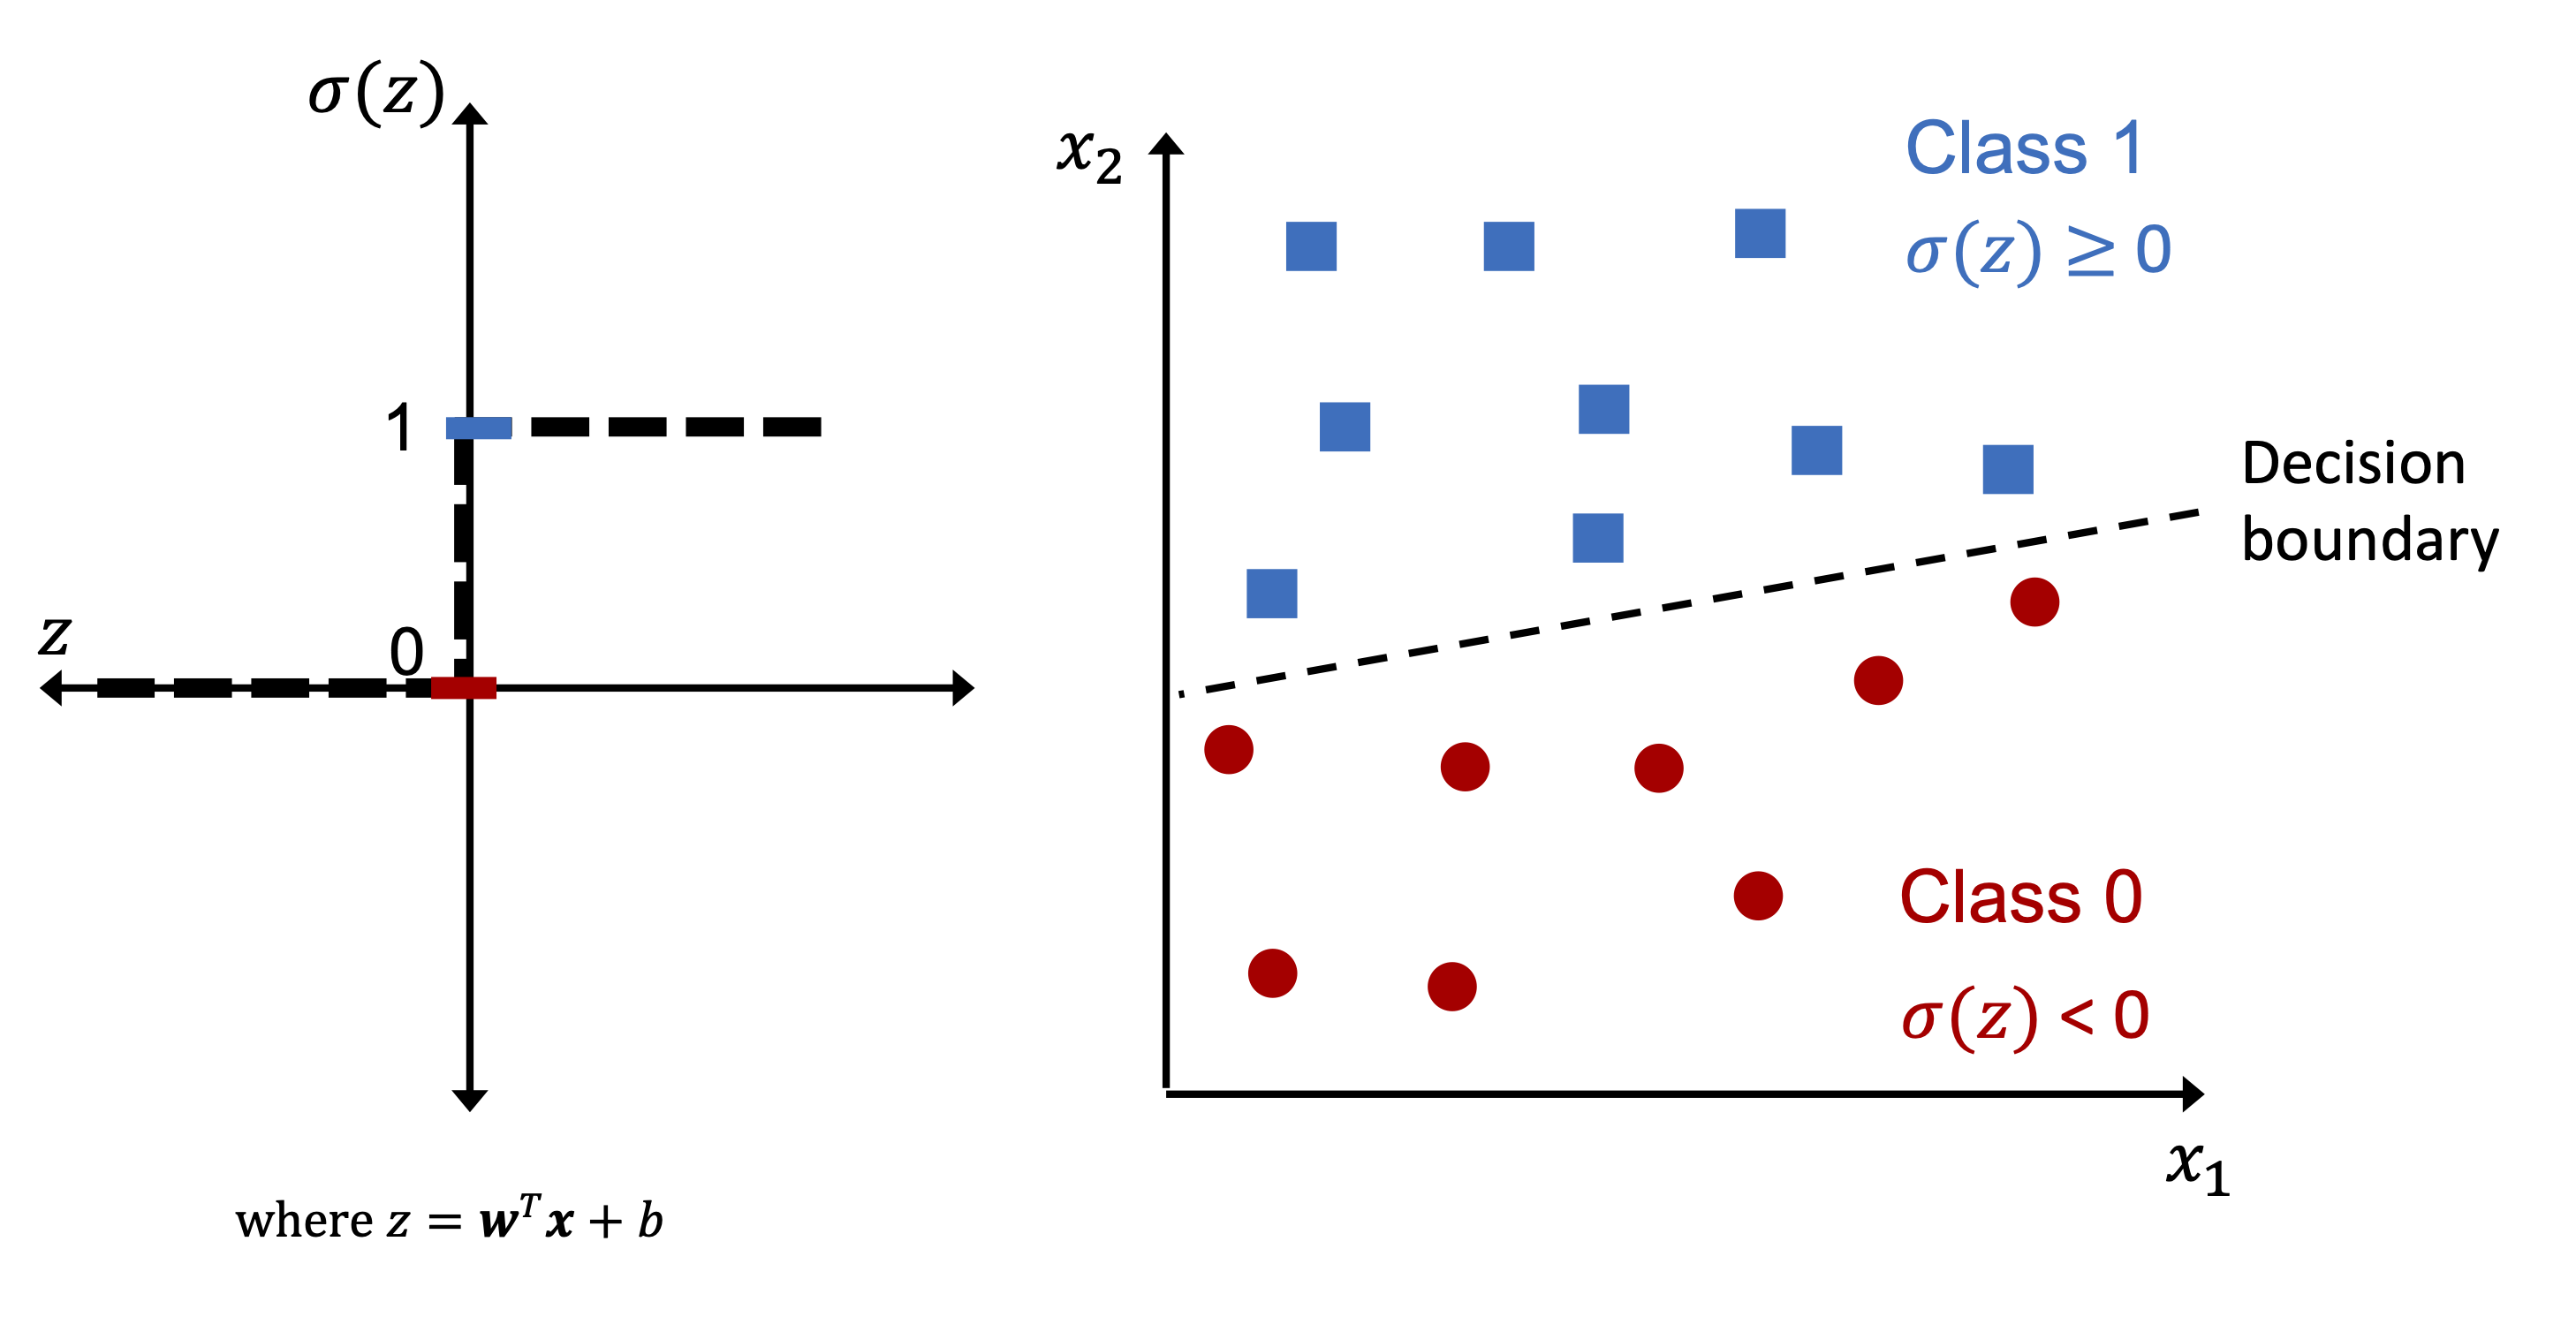

In [1]:
from IPython.display import Image
Image(filename='figures/02_02.png', width=500)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
class Perceptron:
    """Персептронный классификатор.
    Параметры
    ------------
    eta : float
        Скорость обучения (между 0.0 и 1.0)
    п_iter : int
        Кол-во проходов по обучающему набору.
    random_state : int
        Опорное значение генератора случайных чисел для инициализации весов.
    Атрибуты
    ------------
    w_ : ld-array
        Веса после подгонки.
    b_ : Scalar
        Смещение после подгонки.
    errors : list
        Количество неправильных классификаций (обновлений) в каждой эпохе."""

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
    # Определяет конструктор класса с параметрами по умолчанию
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        # Сохраняет переданные параметры как атрибуты объекта класса

    def fit(self, X, y):
        # Метод fit (обучение модели)
        """ Соответствие тренировочным данным.
        Параметры
        ------------
        X : {array-like), shape = [n_examples, n_features]
            Обучающий вектор, где n_examples - это количество образцов,
            a n_features - количество признаков.
        y array-like, shape [n_examples]
            Целевые значения.
        Возвращаемые значения
        ------------
        self : object"""
        rgen = np.random.RandomState(self.random_state)
        #self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.w_ = np.zeros(X.shape[1])

        # X.shape[1] - количество признаков (столбцов) в X
        # loc=0.0 - среднее значение распределения
        # scale=0.01 - стандартное отклонение (маленькие значения для начальной инициализации)
        self.b_ = np.float64(0.)

        self.errors_ = []

        for _ in range(self.n_iter):
        # _ используется как имя переменной, когда значение не используется
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Вычисление фактического входа"""
        return np.dot(X, self.w_) + self.b_
        # np.dot(X, self.w_) вычисляет скалярное произведение X и весов
    def predict(self, X):
        """ Возвращает метки класса после шага """
        return np.where(self.net_input(X) >= 0.0, 1, 0)
        # Применяет пороговую функцию активации (ступенчатую функцию)

#### 2.2.2 Обучение модели персептрона на наборе данных lris 

In [3]:
import os
import pandas as pd

current_dir = os.getcwd()
file_path = os.path.join(current_dir, 'iris.data')
df = pd.read_csv(file_path, header=None, encoding='utf-8')
df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


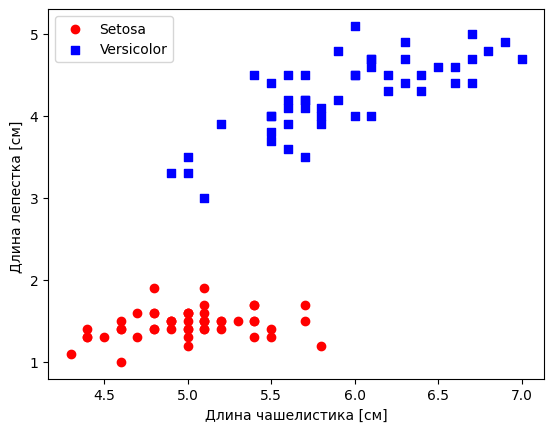

In [4]:
# Выбираем первые 100 строчек из файла (setosa и versicolor)
y = df.iloc[0:100, 4] .values
y = np.where(y == 'Iris-setosa', 0, 1)
# Извлекаем длину чашелистика и длину лепестка
X = df.iloc[0:100, [0, 2]] .values
# Отображаем данные
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],color='blue', marker='s', label='Versicolor')
plt.xlabel ('Длина чашелистика [см]')
plt.ylabel ('Длина лепестка [см] ')
plt.legend(loc='upper left')
plt.show()

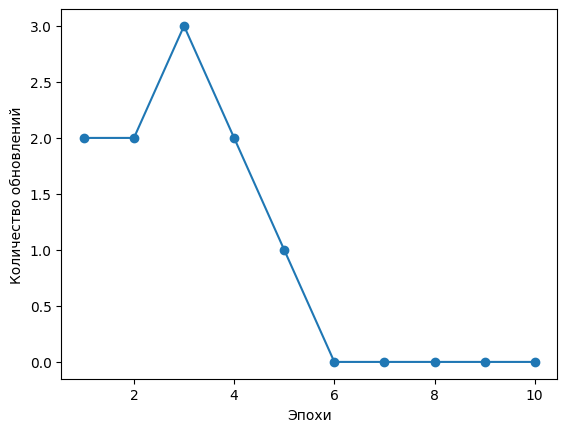

[2, 2, 3, 2, 1, 0, 0, 0, 0, 0]

In [5]:
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn. errors_) + 1),ppn.errors_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Количество обновлений')
plt.show()
display(ppn.errors_)

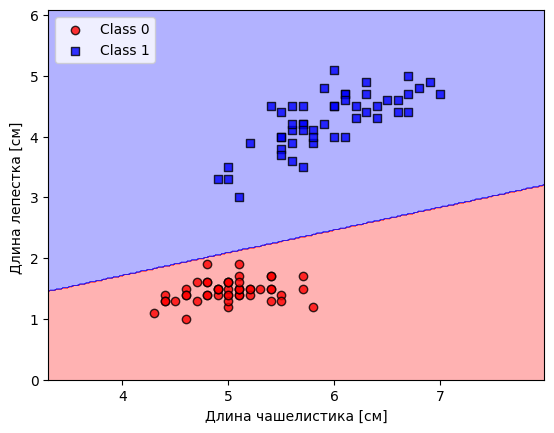

In [6]:
# Визуализация решающих границ для двумерных наборов данных
from matplotlib.colors import ListedColormap
# ListedColormap позволяет создавать собственные цветовые палитры
# resolution=0.02 определяет "разрешение" сетки (шаг между точками)
def plot_decision_regions(X, y, classifier, resolution=0.02):
    # Настройка генератора метки и цветовой карты
    markers = ('o', 's', '^', 'v', '<') # для 5 классов
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    # cmap: создает цветовую карту, используя столько цветов, сколько уникальных классов в y
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # построение решающей поверхности
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    # meshgrid создает сетку точек для первого (xx1) и второго (xx2) признаков
    # (создает все возможные комбинации этих точек)
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    # xx1.ravel() и xx2.ravel() "расплющивают" сетки в 1D массивы
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    # возвращает предсказания обратно в 2D-форму
    lab = lab.reshape(xx1.shape)
    # contourf создает залитые контуры - разные цвета для разных классов
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # построение образцов класса
    # enumerate(np.unique(y)) проходит по всем классам с их индексами
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

plot_decision_regions(X, y, classifier=ppn)
plt.xlabel ('Длина чашелистика [см]')
plt.ylabel ('Длина лепестка [см] ')
plt.legend(loc='upper left')
plt.show()

### 2.3 Адаптивные линейные нейроны (Adaline) и сходимость обучения 

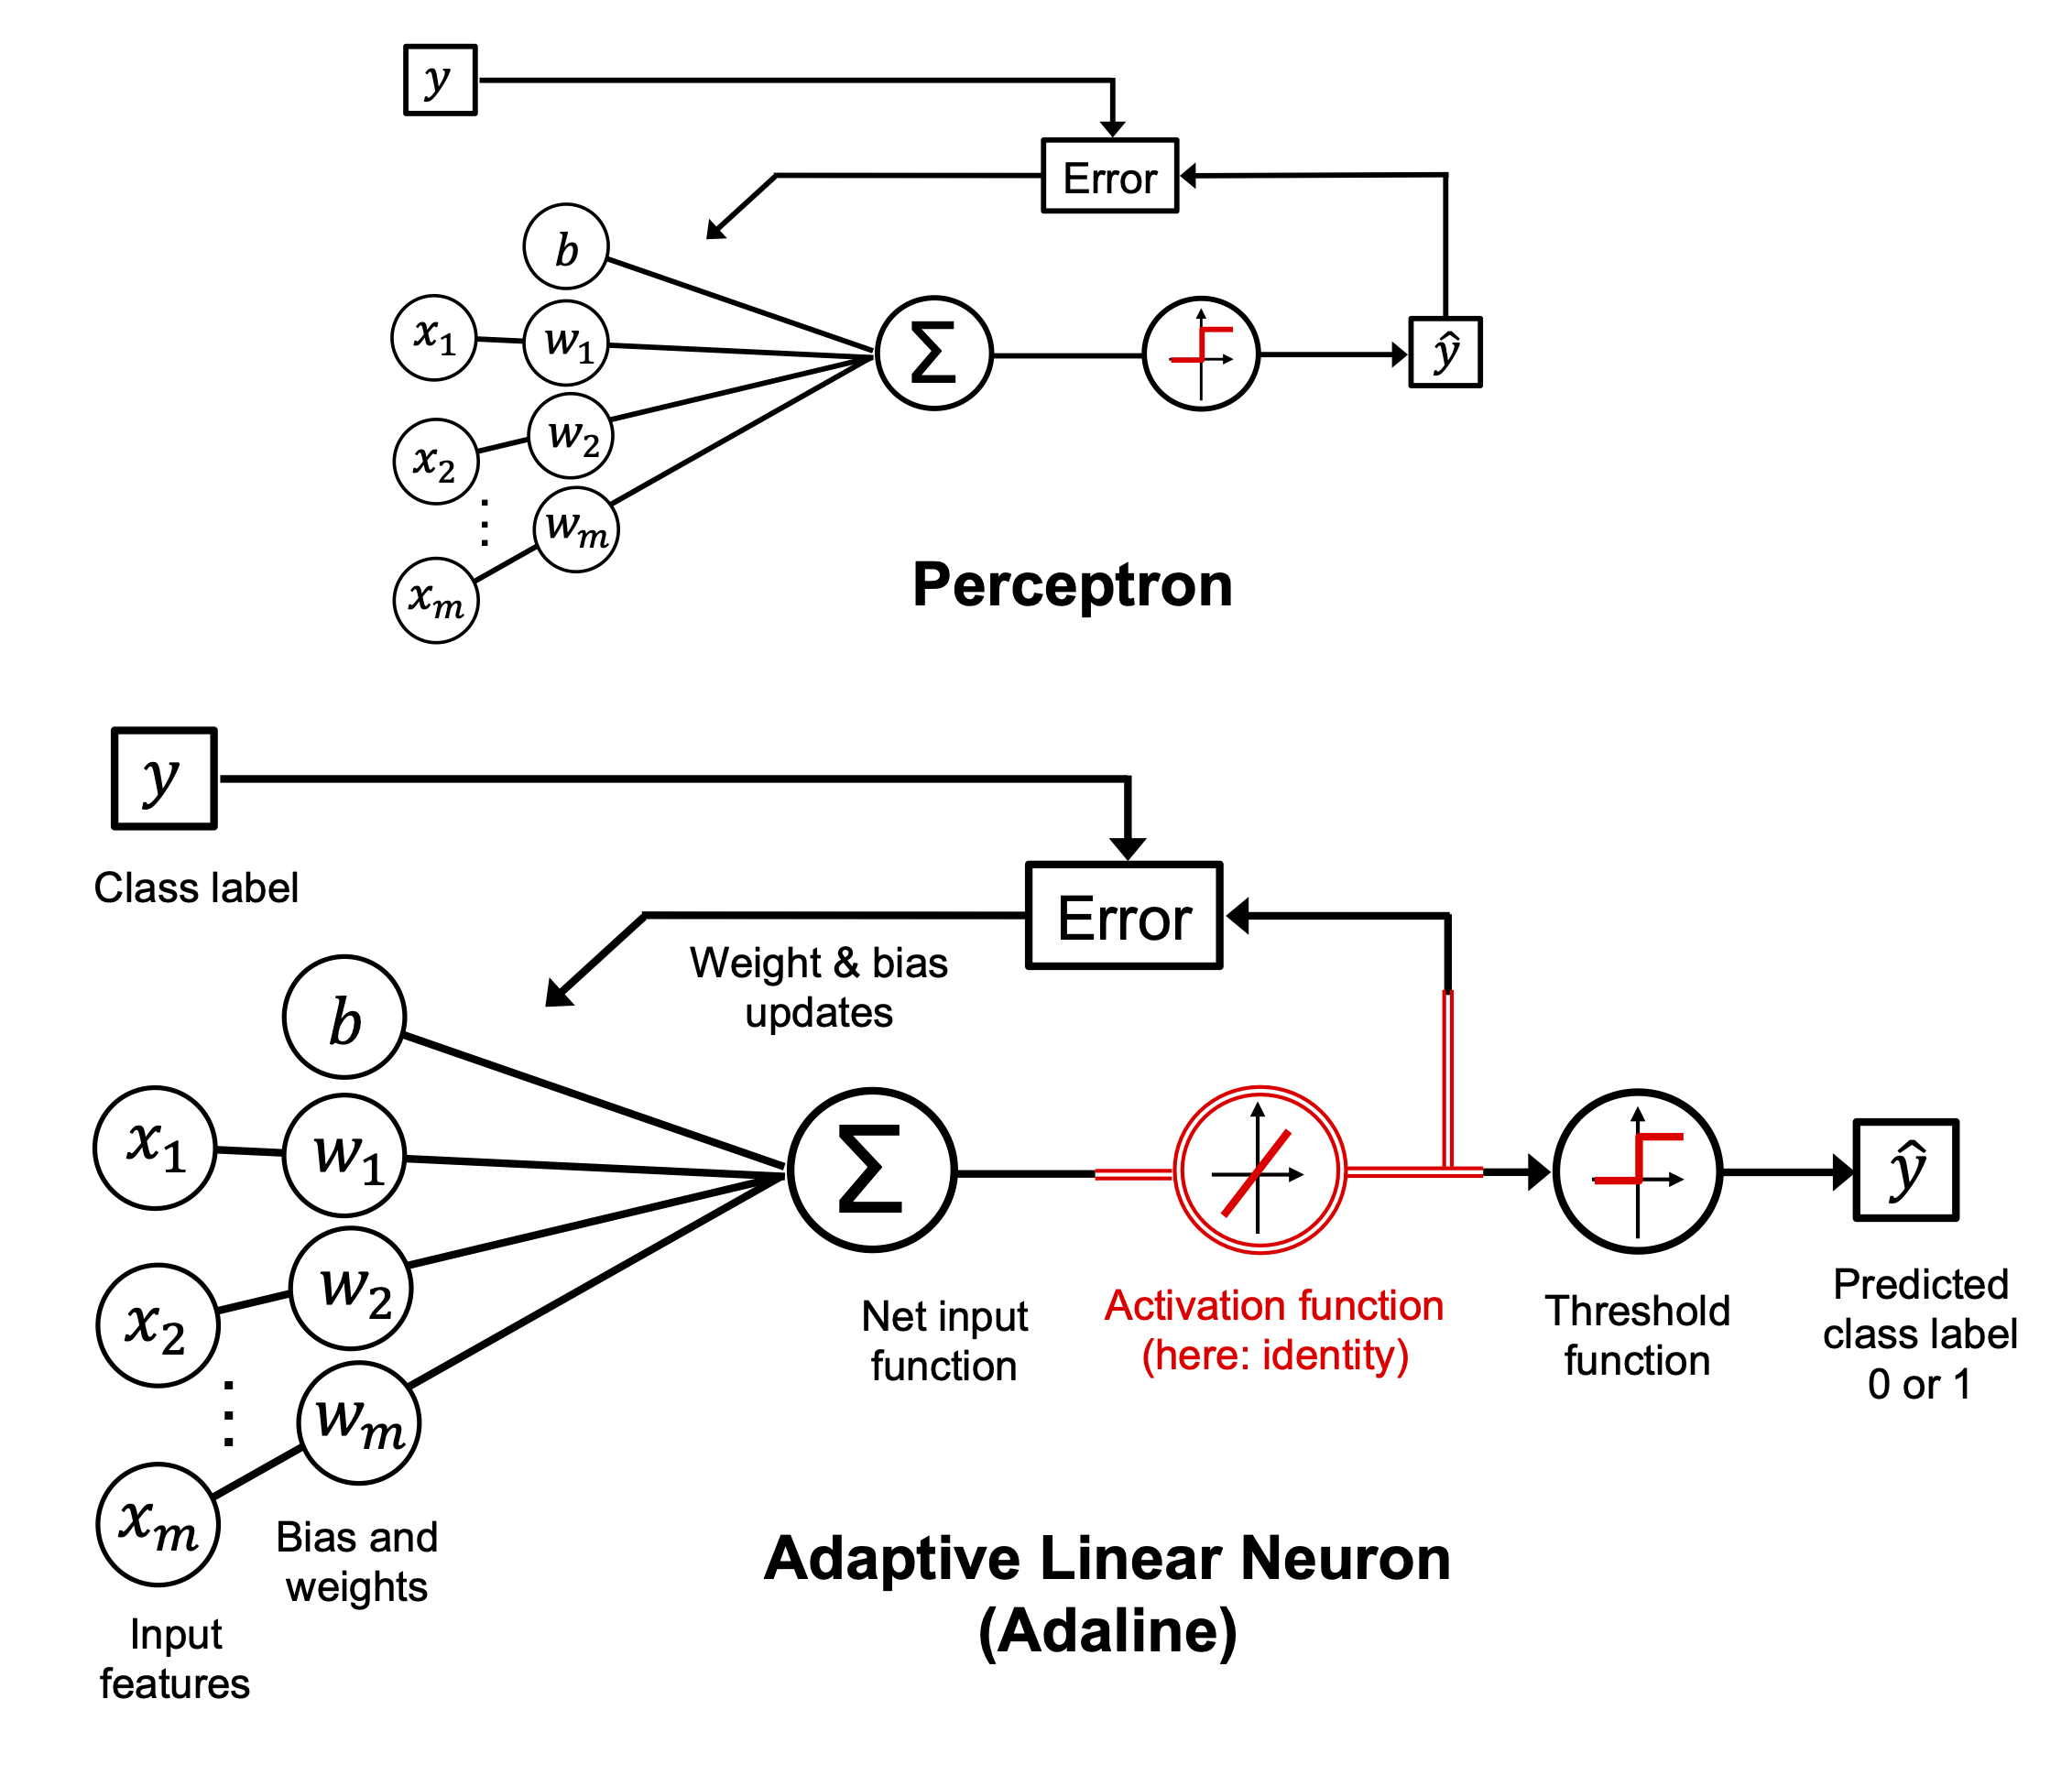

In [7]:
# Основные различия между персептроном и алгоритмом Adaline
Image(filename='figures/02_09.png', width=500)

#### 2.3.1. Минимизация функции потерь с помощью градиентного спуска (полный пакетный градиентный спуск)

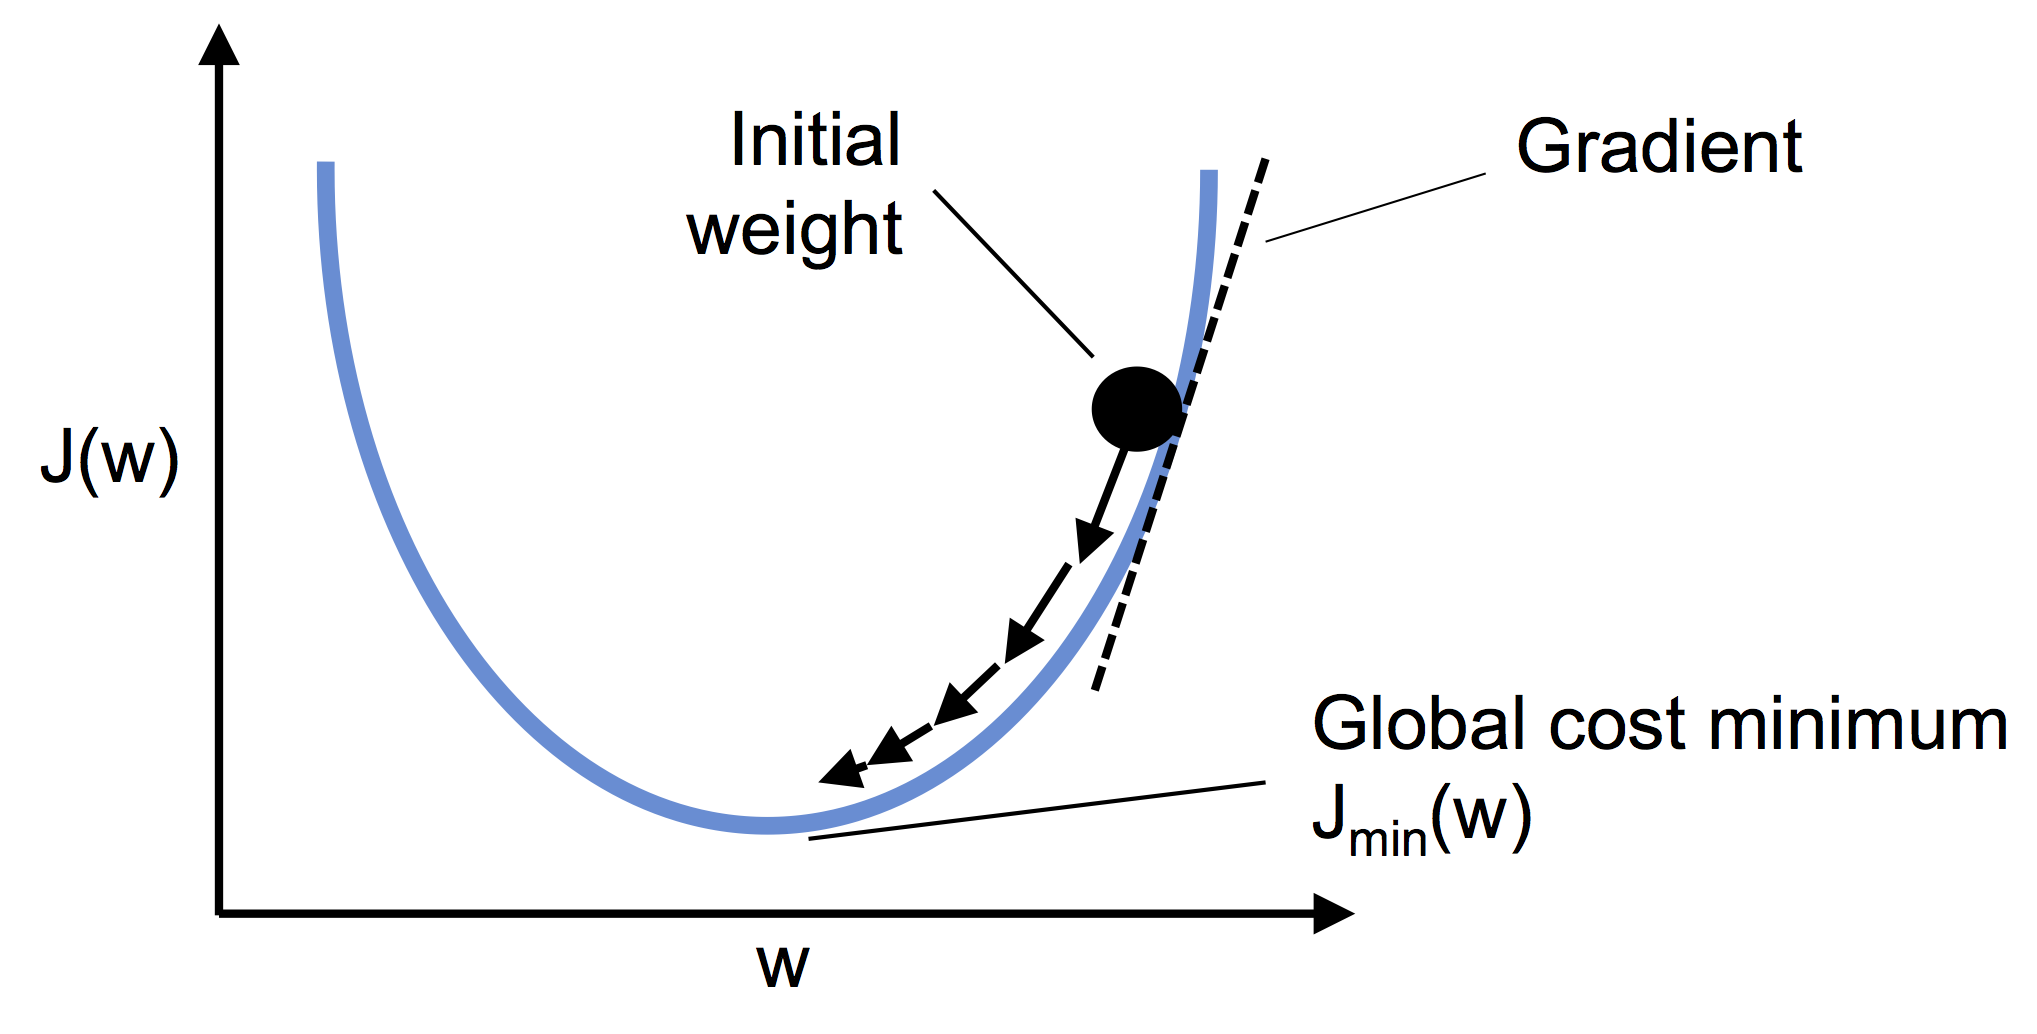

In [8]:
Image(filename='figures/02_10.png', width=500)

#### 2.3.2. Реализация Adaline на Python

In [9]:
class AdalineGD:
    """Классификатор на адаптивных линейных нейронах.
    Параметры
      eta : float
        Скорость обучения (между 0.0 и 1.0)
      n_iter : int
        Количество проходов по обучающему набору.
      random_state : int
        Начальное значение для случайной инициализации весов.
    Атрибуты
      w_ : Одномерный массив
        Веса после обучения.
      b : Скаляр
        Смещение после обучения.
      losses : list
        Значения среднеквадратичной функции потерь после каждой эпохи.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Подгонка к обучающим данным.
        Параметры
          X : {array-like), shape = [n_examples, n_features]
            Обучающие векторы, где n_examples - количество образцов и n_features - количество признаков.
          y array-like, shape = [n examples]
            Целевые переменные.
        Возвращаемые значения
          self : object
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # Пожалуйста, обратите внимание, что метод "activation" не имеет никакого эффекта
            # в коде, поскольку это просто функция идентификации. Вместо этого мы
            # могли бы написать напрямую "output = self.net_input(X)".
            # Цель активации более концептуальна, т.е.,
            # в случае логистической регрессии (как мы увидим позже),
            # мы могли бы изменить ее на
            # сигмовидную функцию, чтобы реализовать классификатор логистической регрессии.
            output = self.activation(net_input)
            errors = (y - output)
            # Вместо обновления весов после оценки на каждом отдельном обучающем образце, как
            # в персептроне, мы вычисляем градиент на основе всего обучающего набора данных.
            # Для смещения это делается при помощи: self.eta * 2.0 * errors.mean()
            # где errors - это массив, содержащий значения частных производных-. Аналогичным образом мы обновляем
            # веса. Однако обратите внимание, что обновления весов через частные производные дL/дw
            # включающие значения признаков х1 вычисляют перемножением errors и каждого
            # значения признака для каждого веса:
            #for w_j in range(self.w_.shape[0]):
            #    self.w_[w_j] += self.eta * (2.0 * (X[:, w_j]*errors)).mean()
            # Чтобы реализовать более эффективное обновление весов без использования цикла for,
            # можно воспользоваться операцией умножения матрицы на вектор и перемножить нашу
            # матрицу признаков и вектор ошибки: self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[O]
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Вычисление фактического ввода"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Вычисление линейной активации"""
        return X

    def predict(self, X):
        """Возвращаем метку класса"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

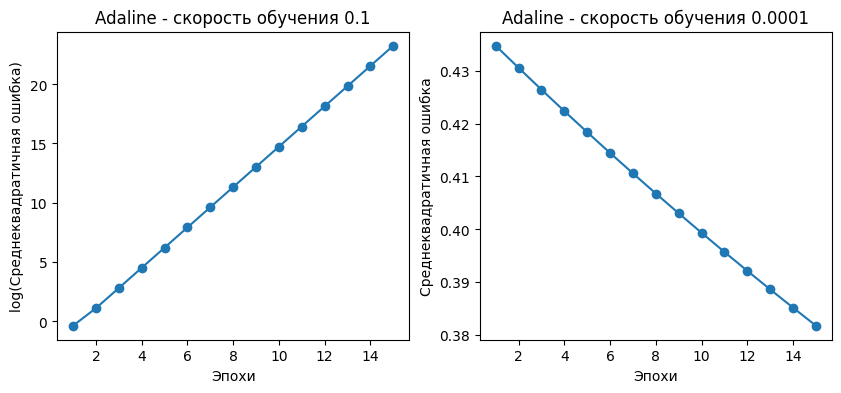

In [10]:
# Теперь построим график потерь в зависимости от количества эпох для двух
# разных скоростей обучения (eta = 0.1 и eta = О.ООО1 ):
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.losses_) + 1), np.log10(ada1.losses_), marker='o')
ax[0].set_xlabel('Эпохи')
ax[0].set_ylabel('log(Среднеквадратичная ошибка)')
ax[0].set_title('Adaline - скорость обучения 0.1')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Эпохи')
ax[1].set_ylabel('Среднеквадратичная ошибка')
ax[1].set_title('Adaline - скорость обучения 0.0001')
plt.show()

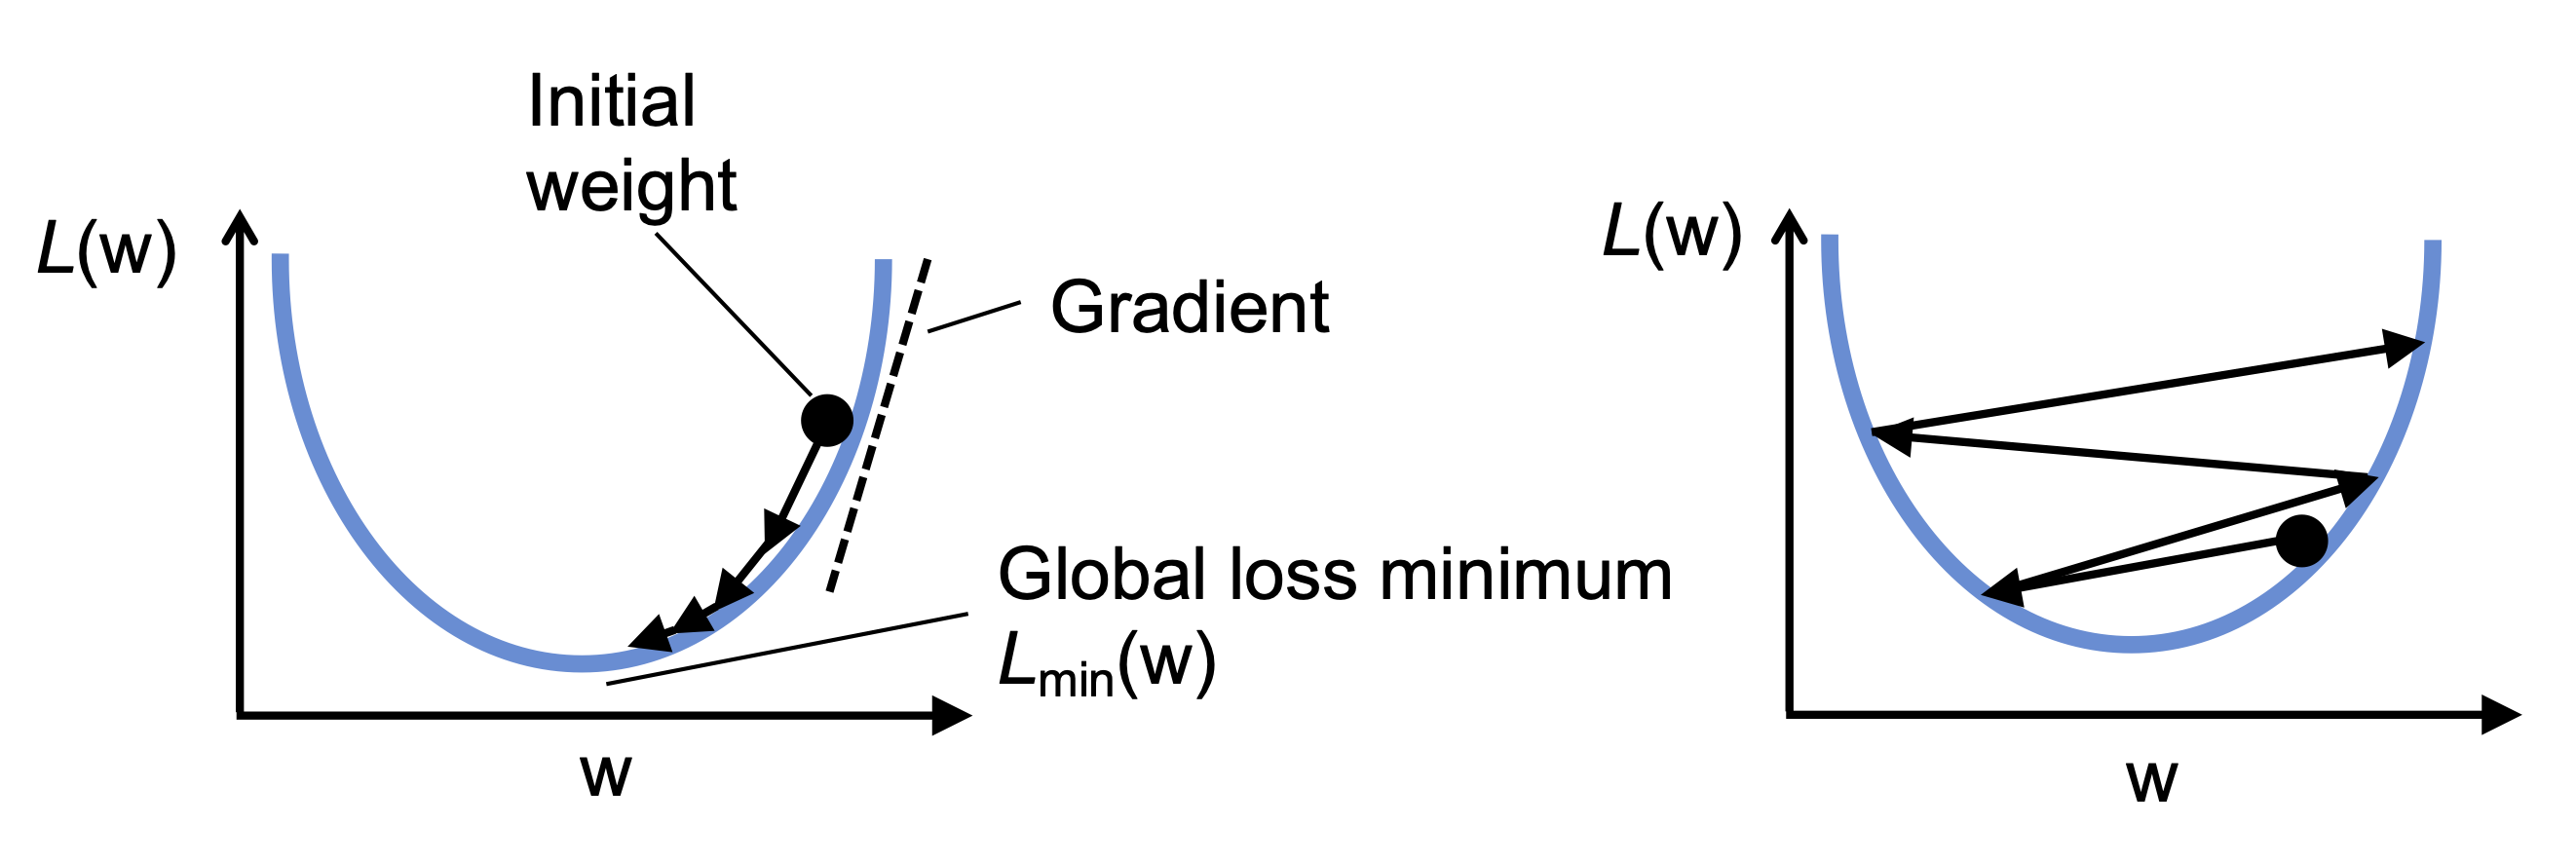

In [11]:
Image(filename='figures/02_12.png', width=700)

#### 2.3.3. Улучшение градиентного спуска за счет масштабирования признаков

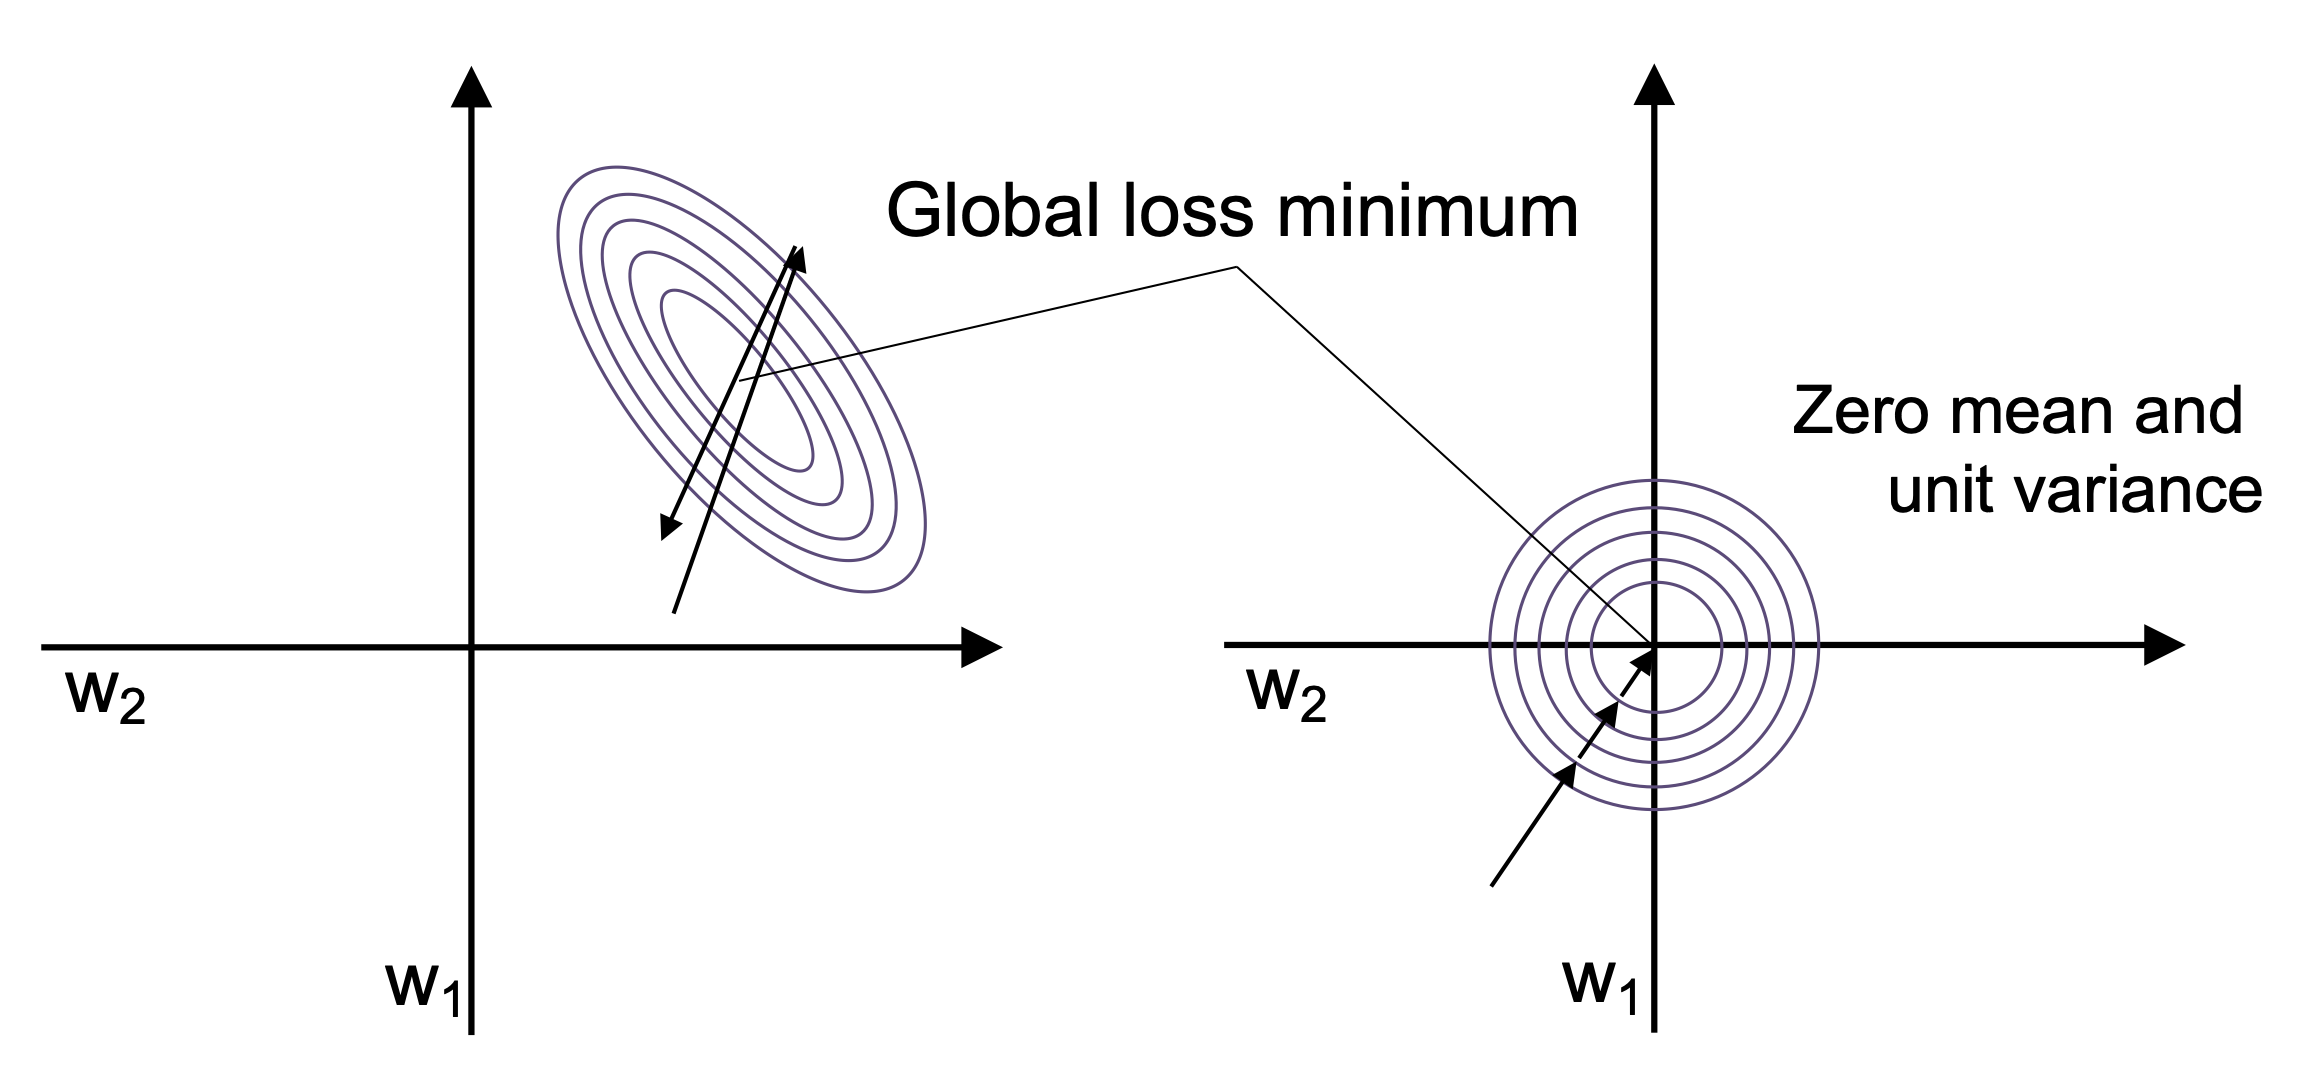

In [12]:
Image(filename='figures/02_13.png', width=500)
# На рис. 2.13 показаны возможные обновления градиента с немасштабированными признаками (слева)
# и стандартизированными признаками (справа). Концентрические окружности представляют поверхность
# потерь как функцию двух весов модели в задаче двумерной классификации.

In [13]:
# Стандартизация признаков
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

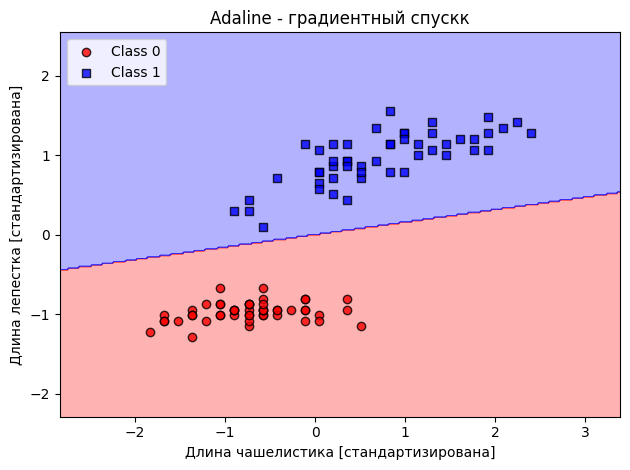

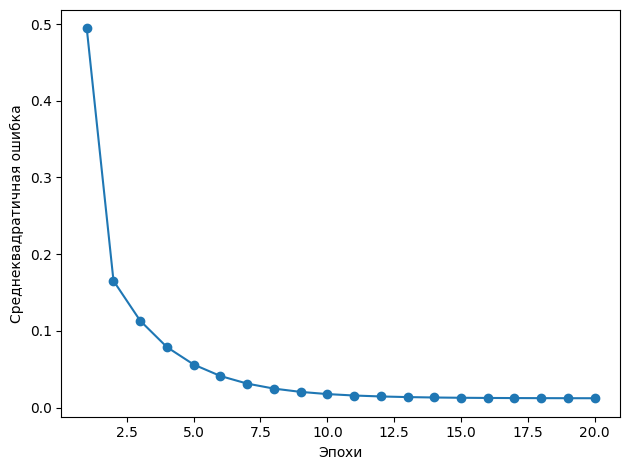

In [14]:
ada_gd = AdalineGD(n_iter=20, eta=0.5)
ada_gd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - градиентный спускк')
plt.xlabel('Длина чашелистика [стандартизирована]')
plt.ylabel('Длина лепестка [стандартизирована]')
plt.legend(loc='upper left')
plt.tight_layout()
#plt.savefig('images/02_14_1.png', dpi=300)
plt.show()

plt.plot(range(1, len(ada_gd.losses_) + 1), ada_gd.losses_, marker='o')
plt.xlabel('Эпoxи')
plt.ylabel('Среднеквадратичная ошибка')

plt.tight_layout()
plt.show()

#### 2.3.4. Крупномасштабное машинное обучение и стохастический градиентный спуск 

In [15]:
class AdalineSGD:
    """Классификатор на адаптивных линейных нейронах.

    Параметры
    eta : float
      Скорость обучения (между 0.0 и 1.0)
    n_iter : int
      Количество проходов по обучающему набору.
    shuffle : bool (default: True)
      Перемешивание обучающих данных каждую эпоху, если задано True, для предотвращения возникновения циклов.
    random_state : int
      Затравка генератора случайных чисел для инициализации весов случайными значениями.

    Атрибуты
      w_ : Одномерный массив
        Веса после обучения.
      b : Скаляр
        Смещение после обучения.
      losses : list
        Значения среднеквадратичной функции потерь после каждой эпохи.
    """
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        """ Подгонка к обучающим данным.
        Параметры
          X : {array-like), shape = [n_examples, n_features]
            Обучающие векторы, где n_examples - количество образцов и n_features - количество признаков.
          y array-like, shape = [n examples]
            Целевые переменные.
        Возвращаемые значения
          self : object
        """
        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        """Подгонка к обучающим данным без повторной инициализации весов"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self
    # Если нам нужно обновить модель, например в сценарии постепенного обучения на потоковых данных,
    # мы можем просто вызвать метод partial _fit для отдельных обучающих примеров
    # например: ada_sgd.partial _ fit(X_std[0, :], у[0]).

    def _shuffle(self, X, y):
        """Перемешивание обучаюших данных"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        """Инициализация весов небольшими обучаюшими данными"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Применение правила Adaline для обновления весов"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_ += self.eta * 2.0 * xi * (error)
        self.b_ += self.eta * 2.0 * error
        loss = error**2
        return loss

    def net_input(self, X):
        """Вычисление фактического ввода"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Вычисление линейной активации"""
        return X

    def predict(self, X):
        """Возвращаем метку класса"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

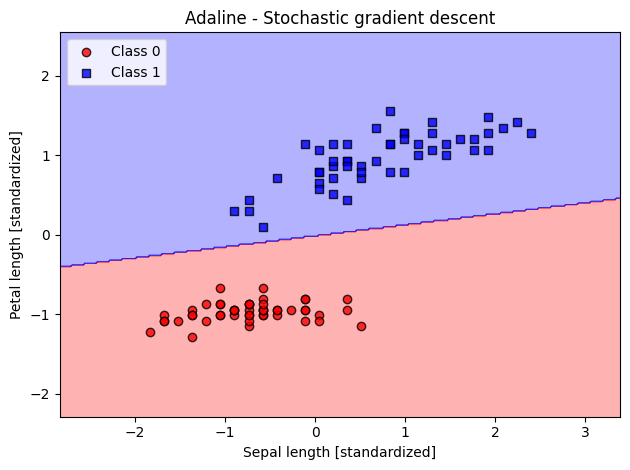

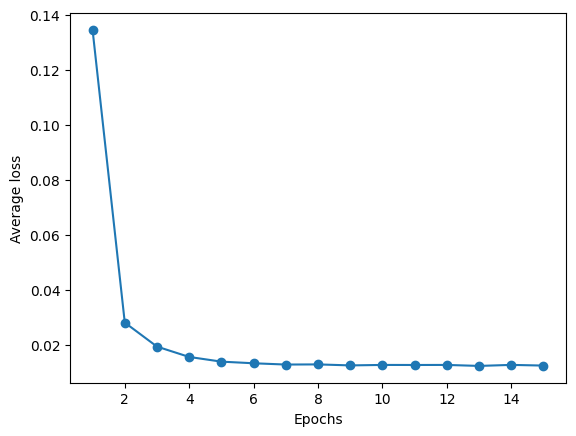

In [16]:
ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average loss')
plt.show()